In [25]:
import sys
import os
sys.path = [p for p in sys.path if "ParaView" not in p]
sys.path.append("/home/haseeb/Notebooks/Parameteric_DMD_cylinder_2D_modules")
import math
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.patches import Circle, Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from flowtorch import DATASETS
from flowtorch.data import FOAMDataloader, mask_box
from flowtorch.analysis import DMD
import seaborn as sns
from sklearn.utils.extmath import randomized_svd
from scipy.interpolate import griddata

from pathlib import Path
import re
# For High Quality Visuals
import matplotlib as mpl
mpl.rcParams['mathtext.fontset'] = 'cm'   # Computer Modern
mpl.rcParams['figure.dpi'] = 160  # crisp visuals

## Step 1. Defining training and test parameters

We define a training set *P*, for the partitioned Dynamic Mode Decomposition as:
$$
P = \{\mu_1, \mu_2, \dots, \mu_P\}, \quad 
\mu_j \equiv Re_j $$

where
- $P$ : set of training parameters which are Reynolds numbers $Re$ in this case. 
- $\mu_j$ : $j$‑th training parameter in $P$ 

And, the unseen parameter is given as $\mu^\star$, for which the spectral information ($\lambda$, $\phi$, $b$) of the forecasted DMD from the training set $P$ is interpolated.

$$
\mu^\star \equiv Re^\star
$$

where 
- $\lambda_j^{(\mu_j)}$ : DMD eigenvalue associated with mode $j$ at parameter $\mu_j$
- $\phi_j^{(\mu_j)}$: $j$‑th DMD mode vector  
- $Re^\star$: test Reynolds number
- $b_{jk}^{(\mu_j)}$: amplitude of mode $j$ at time $k$


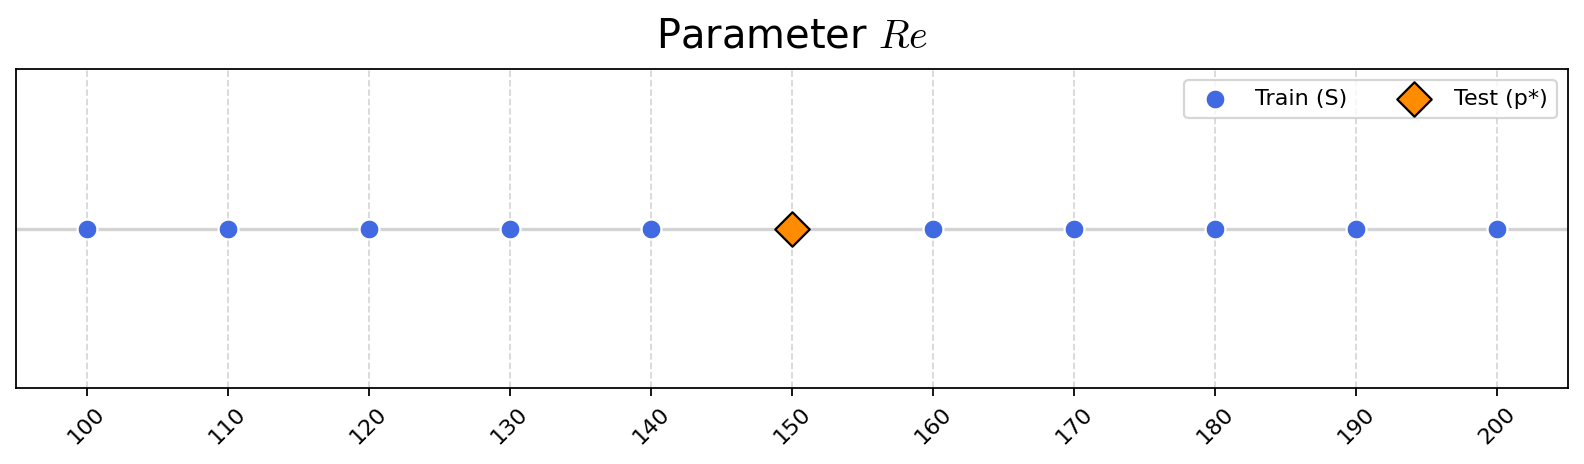

In [4]:
# Training and test parameters (parameter set P and test parameter μ*)

# Training parameter set P = {μ1, ..., μP}, i.e., Reynolds numbers
Re_list = np.array([100, 110, 120, 130, 140, 160, 170, 180, 190, 200])  # μ: training parameters

# Test parameter μ* (unseen Reynolds number)
Re_test = 150  # μ*: test parameter
# Global reference length and viscosity
L_ref = 0.1   # cylinder diameter [m]
nu = 1e-3     # kinematic viscosity [m^2/s] (example value, adjust to your case)

# Geometry parameters (from your blockMeshDict)
cylinderX = 0.2   # cylinder center x [m]
cylinderY = 0.2   # cylinder center y [m]
radius    = 0.05  # cylinder radius [m]


# Calculate reference velocities for non-dimensionalization directly from Re
U_ref_dict = {Re: Re * nu / L_ref for Re in Re_list}
U_ref_test = Re_test * nu / L_ref

# Visualization of parameter set S and test parameter p*
fig, ax = plt.subplots(figsize=(10, 3))
plt.title('Parameter $Re$', fontsize=18, pad=10)

# Plot all training parameters (S)
ax.scatter(Re_list, np.zeros_like(Re_list), 
           marker='o', s=80, color='royalblue', edgecolor='white', 
           label='Train (S)', zorder=3)

# Plot test parameter (p*)
ax.scatter(Re_test, 0, 
           marker='D', s=120, color='darkorange', edgecolor='black', 
           label='Test (p*)', zorder=4)

# Formatting
plt.xticks(np.append(Re_list, Re_test), rotation=45, fontsize=10)
plt.yticks([])
ax.axhline(0, color='lightgray', linewidth=1.5, zorder=1)   # baseline line
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(ncols=2, frameon=True, fontsize=10)

plt.tight_layout()
plt.show()


In [5]:
# Load and prepare data (velocity components Ux, Uy)

import os
from Flowtorch_DMD_cylinder_2D_modules import loader

# Base folder containing simulation data
base_path = os.path.expanduser("~/OpenFOAM/test_1")

# Time windows
training_window = (10.0, 15.0)  # training window T: snapshots used to build X^(μ)
future_window   = (15.0, 20.0)  # forecast window T_future: snapshots used for validation

# Sampling step for downsampling time steps
sampling_step = 1


# Load training and future snapshots for all training parameters μ ∈ P
# (velocity only: [Ux; Uy])

train = loader.load_training_snapshots(
    Re_list=Re_list,                 # P: training parameter set
    base_path=base_path,
    mask_box=mask_box,
    FOAMDataloader=FOAMDataloader,
    training_window=training_window, # T: training time instants
    future_window=future_window,     # T_future: forecast time instants
    sampling_step=sampling_step
)

# Access training data
snapshot_dict             = train.snapshots              # X^(μ): stacked [Ux; Uy] snapshots
sampled_times_dict        = train.times                  # T: training time instants
snapshot_future_dict      = train.future_snapshots       # X_future^(μ): stacked future snapshots
sampled_times_future_dict = train.future_times           # T_future: forecast time instants
masked_coords_dict        = {Re: train.coords for Re in Re_list}  # spatial coordinates after masking
num_points_dict           = {Re: train.num_points for Re in Re_list}  # number of spatial points after masking


# Load test snapshots for unseen parameter p* (forecast-aligned only)
# (velocity only: [Ux; Uy])

# Use the same future times as training
future_times = sampled_times_future_dict[Re_list[0]]

path_test = f"{base_path}/cylinder_2D_Re{Re_test}"

test_data = loader.load_test_snapshots(
    Re=Re_test,                       # p*: test parameter
    path=path_test,
    mask_box=mask_box,
    FOAMDataloader=FOAMDataloader,
    future_times=future_times,        # T_future: forecast time instants
    sampling_step=sampling_step
)

# Access test forecast data
snapshot_test_future      = test_data.test_future_snapshots     # X_future^(p*): stacked [Ux; Uy] forecast snapshots
sampled_times_test_future = test_data.test_future_times         # T_future: forecast time instants for test p*
mask_test                 = test_data.mask
coords_test               = test_data.coords
num_points_test           = test_data.num_points


[2026-04-07 20:43:48] INFO     Loading precomputed cell centers and volumes from processor0/constant
[2026-04-07 20:43:48] INFO     Loading precomputed cell centers and volumes from processor1/constant


Loaded training and future snapshots for Re=100
Loaded training and future snapshots for Re=110
Loaded training and future snapshots for Re=120
Loaded training and future snapshots for Re=130
Loaded training and future snapshots for Re=140
Loaded training and future snapshots for Re=160
Loaded training and future snapshots for Re=170
Loaded training and future snapshots for Re=180
Loaded training and future snapshots for Re=190


[2026-04-07 20:44:20] INFO     Loading precomputed cell centers and volumes from processor0/constant
[2026-04-07 20:44:20] INFO     Loading precomputed cell centers and volumes from processor1/constant


Loaded training and future snapshots for Re=200
Loaded test future snapshots for Re=150



## Step 2. Train partitioned DMD

For each training parameter $\mu_j \in P = \{\mu_1, \mu_2, \dots, \mu_p\}$ i.e., Reynolds numbers $Re$, the fitted DMD operator is obtained via

$$
A^{(\mu_j)} \;\; \approx \;\; Y^{(\mu_j)} \, \big(X^{(\mu_j)})^{\dagger}
$$


where  
- $\mu_j$ : $j$‑th training parameter in the set $S$  
- $Re$ : Reynolds number corresponding to $\mu_j$  
- $X^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times (n_{\text{time}}-1)}$ : snapshot matrix at times $t_1, \dots, t_{n_{\text{time}}-1}$  
- $Y^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times (n_{\text{time}}-1)}$ : shifted snapshot matrix at times $t_2, \dots, t_{n_{\text{time}}}$  
- $A^{(\mu_j)}$ : DMD regression operator advancing the reduced state forward in time  



In [6]:
dmd_dict = {}

for Re in Re_list:
    # Snapshot matrix X^(p) ∈ ℝ^(space_dim × n_time)
    snapshots_np = snapshot_dict[Re]
    X_p = pt.tensor(snapshots_np, dtype=pt.float64)

    # Fit DMD models for each training parameter i.e., Reynolds number

    # - tlsq=True → Total Least Squares DMD (TDMD, Hemati et al.)
    # - unitary=True → piDMD (unitary operator constraint, Baddoo)
    # - optimal=True → spDMD (optimal amplitudes via LSQ, Janovic et al.)
    # - forward_backward=True → CDMD (forward/backward consistency, Azencot et al.)
    

    # Operator A ≈ Y X^+ where:
    dmd = DMD(X_p, dt=0.01, rank=30, tlsq=False, unitary=False, optimal=False, forward_backward=False)

    # Store the DMD object for this Reynolds number
    dmd_dict[int(Re)] = dmd



[2026-04-07 20:44:22] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-07 20:44:22] INFO     Truncating SVD at index 30/500
[2026-04-07 20:44:22] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-07 20:44:22] INFO     Truncating SVD at index 30/500
[2026-04-07 20:44:22] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-07 20:44:22] INFO     Truncating SVD at index 30/500
[2026-04-07 20:44:23] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-07 20:44:23] INFO     Truncating SVD at index 30/500
[2026-04-07 20:44:23] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-07 20:44:23] INFO     Truncating SVD at index 30/500
[2026-04-07 20:44:23] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-07 20:44:23] INFO     Truncating SVD at index 30/500
[2026-04-07 20:44:23] INFO     Computing economy SVD via Gram matrix and eig

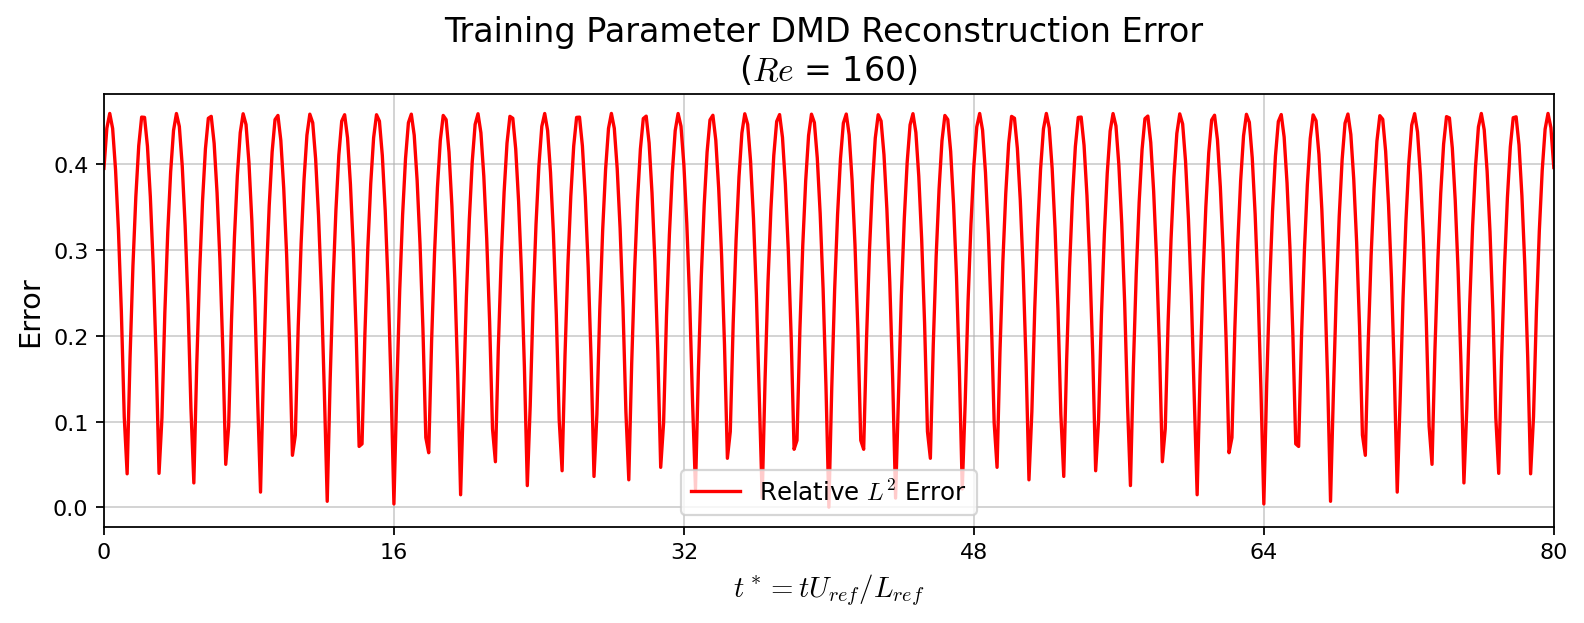

In [7]:
# Plot DMD reconstruction error for training parameter i.e., Reynolds number

# Target Reynolds number
Re = 160

# True snapshot matrix: X_true ∈ ℝ^(n_space × n_time)
X_true = snapshot_dict[Re]

E = dmd_dict[Re].reconstruction_error.detach().cpu().numpy()

# Time vector (shifted so t=0 at first snapshot)
time_vec = np.array(sampled_times_dict[Re], dtype=float)
time_vec = time_vec - time_vec[0]

# Non‑dimensional time: t* = t U_ref / L_ref
U_ref = U_ref_dict[Re]
time_nd = time_vec * U_ref / L_ref

# Absolute and relative L2 error over time
abs_error = np.linalg.norm(E, axis=0)
rel_error = abs_error / np.linalg.norm(X_true, axis=0)
# Plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(time_nd, rel_error, label="Relative $L^2$ Error", color="red")

ax.set_xlabel(r"$t^* = t U_{ref}/L_{ref}$", fontsize=13)
ax.set_ylabel("Error", fontsize=13)
ax.set_title(f"Training Parameter DMD Reconstruction Error \n($Re$ = {Re})",
             fontsize=15)

ax.grid(True, alpha=0.6)
ax.legend(fontsize=11)

ax.set_xlim(time_nd[0], time_nd[-1])
ax.set_xticks(np.linspace(time_nd[0], time_nd[-1], 6))

plt.tight_layout()
plt.show()


## Step 3. Forecasting

 For each training parameter $\mu_j \in P = \{\mu_{\scriptstyle 1}, \mu_{\scriptstyle 2}, \dots, \mu_p\}
$ i.e., Reynolds numbers $Re$, the forecast snapshots at unseen time instants are $X_{\text{forecast}}^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times n_{\text{forecast}}}$
 $$X_{\text{forecast}}^{(\mu_j)}(t^\star) \;\; \text{with } t^\star \in \{t_1, t_2, \dots, t_{n_{\text{forecast}}}\}.
 $$ 

where  
- $\mu_j$ : $j$‑th training parameter in the set $P$  
- $n_{\text{space}}$ : number of spatial degrees of freedom  
- $n_{\text{forecast}}$ : number of forecast time instants  
- $t^\star$ : a specific forecast instant chosen from the forecast window (e.g., for comparison with true data)


In [8]:
forecast_dict = {}

# Forecast horizon
n_steps = 500
dt = 0.01

for Re, dmd_model in dmd_dict.items():
    
    # Initial condition: last true training snapshot
    x0 = snapshot_dict[Re][:, -1]                      # shape (n_space,)
    x0 = pt.tensor(x0, dtype=pt.float32)    

    # Forecast trajectory X̂^(Re)(t) ∈ ℝ^(n_space × (n_steps+1))
    X_forecast = dmd_model.predict(x0, n_steps=n_steps).detach().cpu().numpy()

    # Forecast start time = last training snapshot time
    t0_forecast = float(sampled_times_dict[Re][-1])

    # Store forecast results
    forecast_dict[Re] = {
        "t_forecast": t0_forecast + np.arange(n_steps + 1) * dt,  # forecast time vector
        "X_forecast": X_forecast}                                 # forecast trajectory 

    print(f"Re = {Re}: forecasted trajectory shape = {forecast_dict[Re]['X_forecast'].shape}")


Re = 100: forecasted trajectory shape = (11492, 501)
Re = 110: forecasted trajectory shape = (11492, 501)
Re = 120: forecasted trajectory shape = (11492, 501)
Re = 130: forecasted trajectory shape = (11492, 501)
Re = 140: forecasted trajectory shape = (11492, 501)
Re = 160: forecasted trajectory shape = (11492, 501)
Re = 170: forecasted trajectory shape = (11492, 501)
Re = 180: forecasted trajectory shape = (11492, 501)
Re = 190: forecasted trajectory shape = (11492, 501)
Re = 200: forecasted trajectory shape = (11492, 501)


## Step 4. Interpolation  

### Step 4.1.1 Mode importance sorting  
Modes are ranked using their **integral contribution** following Kou et al. (2017).  


#### Integral contribution-based sorting  
The integral contribution of mode $j$ at parameter $\mu$ is defined as:

$$
I_j^{(\mu)} \;=\; \big\|\phi_j^{(\mu)}\big\|_2^2 \;\cdot\; \sum_{k=1}^{N_s} \big| d_j(t_k;\mu) \big|
$$

- $I_j^{(\mu)}$: importance index of mode $j$ at parameter $\mu$  
- $\phi_j^{(\mu)}$: $j$‑th DMD mode vector at parameter $\mu$  
- $\|\cdot\|_2$: Euclidean norm (spatial energy of the mode)  
- $d_j(t_k;\mu)$: time‑dependent coefficient trajectory of mode $j$ at snapshot $k$ for parameter $\mu$  
- $N_s$: number of forecast snapshots  

**Reference:**  
Kou, J., Zhang, W., & Liu, H. (2017). *Dynamic mode decomposition with arbitrary sampling points*.  
European Journal of Mechanics - B/Fluids, 62, 45–55.  
DOI: [10.1016/j.euromechflu.2016.11.015](https://doi.org/10.1016/j.euromechflu.2016.11.015)  

### Step 4.1.2 Conjugate pair ordering  
Complex eigenvalues occur in conjugate pairs. To ensure consistency across parameters, pairs are ordered such that the eigenvalue with **positive imaginary part** precedes its conjugate with **negative imaginary part**.  

Formally, for each conjugate pair $(\lambda_j^{(\mu)}, \lambda_k^{(\mu)})$ with  

$$
\lambda_k^{(\mu)} \;=\; \overline{\lambda_j^{(\mu)}},
$$  

the ordering is defined as  

$$
\big( \lambda_j^{(\mu)}, \lambda_k^{(\mu)} \big) \quad \text{with} \quad \Im\!\left(\lambda_j^{(\mu)}\right) \;\geq\; 0.
$$  

The corresponding mode vectors and coefficients are permuted in the same way:  

$$
\big( \phi_j^{(\mu)}, \phi_k^{(\mu)} \big), 
\qquad
\big( d_j^{(\mu)}, d_k^{(\mu)} \big).
$$  

### Step 4.1.3 Phase alignment (MRPWI)  
Even after sorting and ordering, modes may differ by an arbitrary complex phase. To remove this ambiguity, each mode is **phase‑aligned** with a chosen reference case (e.g. the Reynolds number closest to the target).  

For mode $j$ at parameter $\mu$, the alignment factor is:  

$$
\theta_j^{(\mu)} \;=\; \arg \Big( \langle \phi_j^{(\mu)}, \phi_j^{(\mu_{\text{ref}})} \rangle \Big)
$$  

The aligned mode and its coefficients are then rotated by $\exp(-i \theta_j^{(\mu)})$, ensuring consistent phase across parameters.

In [9]:
selected_modes_dict   = {}
selected_eigvals_dict = {}

dt = 0.01  # forecast snapshot spacing

top_k = dmd_model.svd.rank  # number of dominant modes to keep

# Temporary storage before alignment
processed_modes_dict = {}

for Re in Re_list:

    # Forecast snapshots X_fore^(Re) ∈ ℝ^(n_space × n_forecast)
    X_fore = forecast_dict[Re]["X_forecast"]

    # Φ^(Re): model basis modes
    Phi = dmd_dict[Re].modes.detach().cpu().numpy()

    # s^(Re): continuous-time eigenvalues
    s = dmd_dict[Re].eigvals_cont.detach().cpu().numpy()

    # Sort by importance
    top_idx = dmd_dict[Re].top_modes(n=len(s), integral=True).detach().cpu().numpy()
    Phi_sorted = Phi[:, top_idx[:top_k]]
    s_sorted   = s[top_idx[:top_k]]

    # Conjugate pair ordering
    ordered_modes, ordered_eigs = [], []
    used = np.zeros(len(s_sorted), dtype=bool)

    for j in range(len(s_sorted)):
        if used[j]:
            continue

        eig = s_sorted[j]
        conj_found = False

        # Conjugate matching
        conj_idx = np.where(np.isclose(s_sorted, np.conj(eig)))[0]

        if len(conj_idx) > 0 and conj_idx[0] != j:
            k = conj_idx[0]
            used[j] = True
            used[k] = True
            conj_found = True

            # Positive imaginary part first
            if np.imag(eig) >= 0:
                ordered_eigs.extend([eig, s_sorted[k]])
                ordered_modes.extend([Phi_sorted[:, j], Phi_sorted[:, k]])
            else:
                ordered_eigs.extend([s_sorted[k], eig])
                ordered_modes.extend([Phi_sorted[:, k], Phi_sorted[:, j]])

        # No conjugate partner (real eigenvalue)
        if not conj_found:
            used[j] = True
            ordered_eigs.append(eig)
            ordered_modes.append(Phi_sorted[:, j])

    ordered_modes = np.column_stack(ordered_modes)
    ordered_eigs  = np.array(ordered_eigs)

    # Store unaligned results
    processed_modes_dict[Re]    = ordered_modes
    selected_eigvals_dict[Re]   = ordered_eigs


# Choose a reference parameter closest to test parameter for alignment
Re_ref  = min(Re_list, key=lambda R: abs(R - Re_test))
Phi_ref = processed_modes_dict[Re_ref]


# Mode re-alignment
for Re in Re_list:

    ordered_modes = processed_modes_dict[Re]

    # Alignment relative to reference case
    aligned_modes = []

    for k in range(ordered_modes.shape[1]):
        phi_ref = Phi_ref[:, k]
        phi_cur = ordered_modes[:, k]

        angle = np.angle(np.vdot(phi_ref, phi_cur))

        aligned_modes.append(phi_cur * np.exp(-1j * angle))

    aligned_modes = np.column_stack(aligned_modes)

    # Store results
    selected_modes_dict[Re] = aligned_modes


In [10]:

# Step 4.2. Interpolation Stencil Selection 
Re_list   = sorted(selected_modes_dict.keys())   # available training Reynolds numbers {μ_j}
Re_test   = Re_test                                          # target parameter μ*

stencil_sets = {}

for Np in [2, 4, 6]:  # desired stencil sizes
    # Ensure even stencil size
    if Np % 2 == 1:
        Np = Np - 1

    # Sort cases by Grassmann distance to target parameter μ*
    # Note: since μ* is unseen, we compare training subspaces to each other
    sorted_neighbors = sorted(
        Re_list,
        key=lambda Re: abs(Re - Re_test)  # parameter proximity for unseen μ*
    )

    # Select Np closest cases {μ_j^1, …, μ_j^Np}
    stencil = sorted_neighbors[:Np]

    # Re‑index sequentially and sort ascending {μ_j}
    stencil = sorted(stencil)

    # Store stencil set for later interpolation of Φ^(μ) and S^(μ)
    stencil_sets[Np] = stencil

print("Selected stencils:", stencil_sets)


Selected stencils: {2: [np.int64(140), np.int64(160)], 4: [np.int64(130), np.int64(140), np.int64(160), np.int64(170)], 6: [np.int64(120), np.int64(130), np.int64(140), np.int64(160), np.int64(170), np.int64(180)]}


## Step 4.3. Modal interpolation (MRPWI)  
Realign the DMD modes across parameters, then interpolate them pointwise using Lagrange weights.

$$
\phi_j^{(μ^*)} = \sum_{i=1}^{N_p} L_i(μ^*) \, \phi_j^{(μ_{ji})}
$$

- $\phi_j^{(μ^*)}$ : interpolated $j$‑th mode at target Reynolds number $μ$*  
- $L_i(μ^*)$ : Lagrange interpolation weight for neighbor $i$, evaluated at $μ$*  
- $\phi_j^{(μ_{ji})}$ : $j$‑th mode at neighbor Reynolds number $μ_{ji}$  
- $N_p$ : stencil size (number of neighbors used)  



In [11]:
# Step 4.3. Lagrange Interpolation of Re-aligned DMD Modes Φ^(μ*) at test parameter μ*

Re_test = Re_test
Nn = selected_modes_dict[Re_list[0]].shape[0]   # spatial dimension n_space
r  = selected_modes_dict[Re_list[0]].shape[1]   # number of retained modes r

# Dictionaries to store interpolated modes
interp_modes_aligned   = {}   # Φ^(μ*) interpolated aligned DMD modes at target parameter
interp_modes_unaligned = {}   # Φ^(μ*) interpolated raw DMD modes at target parameter

for Np, pts in stencil_sets.items():

    # Interpolation of aligned DMD modes Φ^(μ) from selected_modes_dict
    Phi_interp_aligned = np.zeros((Nn, r), dtype=complex)

    for j in range(r):                          # loop over retained modes φ_j
        for k in range(Nn):                     # spatial index
            phi_k_values = [selected_modes_dict[Re][k, j] for Re in pts]  # φ_j^(Re)

            result = 0.0
            for i in range(Np):
                L_i = 1.0                       # Lagrange basis polynomial L_i(μ*)
                for m in range(Np):
                    if m != i:
                        L_i *= (Re_test - pts[m]) / (pts[i] - pts[m])
                result += phi_k_values[i] * L_i

            Phi_interp_aligned[k, j] = result   # φ_j^(μ*)

    interp_modes_aligned[Np] = Phi_interp_aligned   # store Φ^(μ*) aligned


    # Interpolation of raw (unaligned) DMD modes Φ^(μ) from dmd_dict
    Phi_interp_unaligned = np.zeros((Nn, r), dtype=complex)

    for j in range(r):                          # φ_j^(Re) raw
        for k in range(Nn):
            phi_k_values = [
                dmd_dict[Re].modes.detach().cpu().numpy()[k, j]
                for Re in pts
            ]

            result = 0.0
            for i in range(Np):
                L_i = 1.0                       # Lagrange basis polynomial L_i(μ*)
                for m in range(Np):
                    if m != i:
                        L_i *= (Re_test - pts[m]) / (pts[i] - pts[m])
                result += phi_k_values[i] * L_i

            Phi_interp_unaligned[k, j] = result # φ_j^(μ*)

    interp_modes_unaligned[Np] = Phi_interp_unaligned   # store Φ^(μ*) unaligned


## Step 4.4. Eigenvalue interpolation (pointwise)  
Interpolate the continuous‑time eigenvalues across the stencil using Lagrange weights.

$$
s_j^{(\mu^*)} = \sum_{i=1}^{N_p} L_i(\mu^*) \, s_j^{(\mu_{ji})}
$$

- $s_j^{(\mu^*)}$ : interpolated $j$‑th continuous eigenvalue at test Reynolds number $μ*$  
- $L_i(\mu^*)$ : Lagrange interpolation weight for neighbor $i$, evaluated at $μ^*$ 
- $s_j^{(\mu_{ji})}$ : $j$‑th continuous eigenvalue at neighbouring Reynolds number $μ_{ji}$
- $N_p$ : stencil size (number of neighbors used) 


In [12]:
# Step 4.4. Lagrange Interpolation of DMD Eigenvalues s^(μ*) at test parameter μ*

# Dictionaries to store interpolated eigenvalues
interp_eigs_aligned   = {}   # s^(μ*)_aligned interpolated from aligned s^(Re)
interp_eigs_unaligned = {}   # s^(μ*)_unaligned interpolated from raw λ^(Re)

Re_test = Re_test 
r  = selected_eigvals_dict[Re_list[0]].shape[0]   # number of retained modes
dt = 0.01                                         # snapshot spacing (forecast horizon)

for Np, pts in stencil_sets.items():
    # Interpolation of aligned continuous-time eigenvalues s^(Re)
    s_interp_aligned = np.zeros(r, dtype=complex)
    for j in range(r):
        s_j_values = [selected_eigvals_dict[Re][j] for Re in pts]  # s^(Re)_aligned
        result = 0.0
        for i in range(Np):
            L_i = 1.0
            for k in range(Np):
                if k != i:
                    L_i *= (Re_test - pts[k]) / (pts[i] - pts[k])
            result += s_j_values[i] * L_i
        s_interp_aligned[j] = result
    interp_eigs_aligned[Np] = s_interp_aligned   # s^(μ*)_aligned

    # Interpolation of unaligned continuous-time eigenvalues s^(Re) 
    s_interp_unaligned = np.zeros(r, dtype=complex)
    for j in range(r):
        s_j_values = [dmd_dict[Re].eigvals_cont.detach().cpu().numpy()[j] for Re in pts]  # s^(Re)_unaligned
        result = 0.0
        for i in range(Np):
            L_i = 1.0
            for k in range(Np):
                if k != i:
                    L_i *= (Re_test - pts[k]) / (pts[i] - pts[k])
            result += s_j_values[i] * L_i
        s_interp_unaligned[j] = result
    interp_eigs_unaligned[Np] = s_interp_unaligned   # s^(μ*)_unaligned


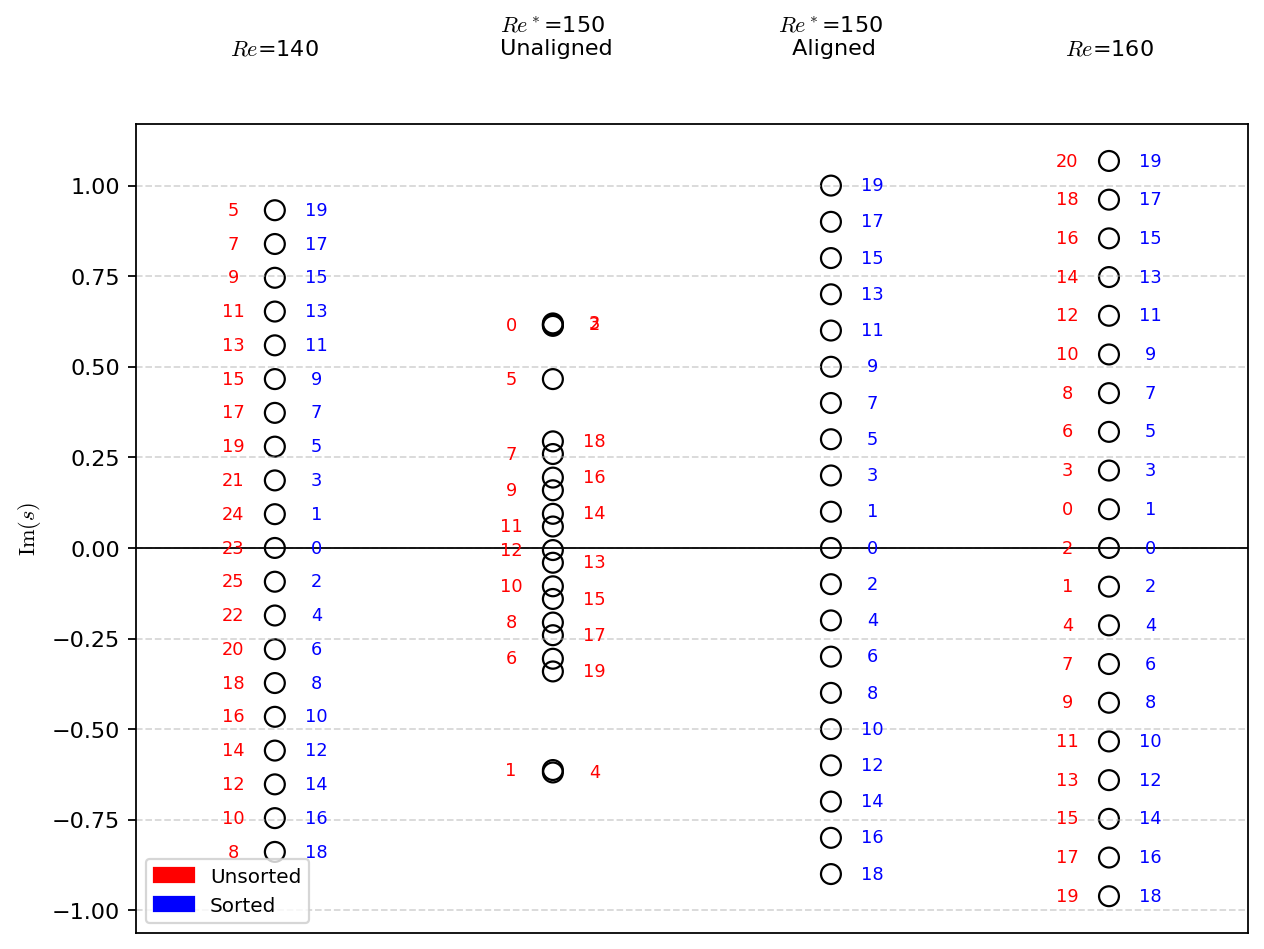

In [13]:
# Plot conjugate pairing and alignment for eigenvalues

# Choose eigenvalues to plot
num_eigs = 20  
Np = 2
# Sort training parameters by proximity to Re_test
sorted_neighbors = sorted(Re_list, key=lambda Re: abs(Re - Re_test))

# Pick the two closest neighbors
Re_left, Re_right = sorted_neighbors[0], sorted_neighbors[1]

# s_raw^(Re): raw continuous-time eigenvalues from DMD
raw_eigs_left  = dmd_dict[Re_left].eigvals_cont.detach().cpu().numpy()
raw_eigs_right = dmd_dict[Re_right].eigvals_cont.detach().cpu().numpy()

# s_ord^(Re): ordered eigenvalues (top-modes + conjugate pairing)
# stored in selected_eigvals_dict
aligned_eigs_left  = selected_eigvals_dict[Re_left][:num_eigs]
aligned_eigs_right = selected_eigvals_dict[Re_right][:num_eigs]

# s_interp_unaligned^(Re_test): interpolated eigenvalues before alignment
# s_interp_al^(Re_test): interpolated eigenvalues after alignment
eigs_interp_unaligned = interp_eigs_unaligned[Np][:num_eigs]
eigs_interp_aligned   = interp_eigs_aligned[Np][:num_eigs]

fig, ax = plt.subplots(figsize=(8, 6))

# Normalization: Im(s) scaled to [-1,1] relative to reference
def normalize_imag_global(eigs, ref_eigs):
    im = np.imag(eigs)
    ref_im = np.imag(ref_eigs)
    max_abs = np.max(np.abs(ref_im))
    return im / max_abs

x_positions = [0, 1, 2, 3]
labels = [f"$Re$={Re_left}",
          f"$Re^*$={Re_test} \n Unaligned",
          f"$Re^*$={Re_test} \n Aligned",
          f"$Re$={Re_right}"]

# Column 0: Left neighbor
y = normalize_imag_global(aligned_eigs_left, eigs_interp_aligned)
ax.scatter([x_positions[0]]*len(y), y, marker='o', facecolors='none', edgecolors='black', s=80)
for aligned_idx, yi in enumerate(y):
    raw_idx = np.where(np.isclose(raw_eigs_left, aligned_eigs_left[aligned_idx]))[0][0]
    ax.text(x_positions[0]-0.15, yi, str(raw_idx), color="red",  ha="center", va="center", fontsize=8)
    ax.text(x_positions[0]+0.15, yi, str(aligned_idx), color="blue", ha="center", va="center", fontsize=8)

# Column 1: Interpolated unaligned
y = normalize_imag_global(eigs_interp_unaligned, eigs_interp_aligned)
ax.scatter([x_positions[1]]*len(y), y, marker='o', facecolors='none', edgecolors='black', s=80)

placed_y = []
tol = 0.05
for k, yi in enumerate(y):
    if any(abs(yi - yj) < tol for yj in placed_y):
        ax.text(x_positions[1]+0.15, yi, str(k), color="red",
                ha="center", va="center", fontsize=8)
    else:
        ax.text(x_positions[1]-0.15, yi, str(k), color="red",
                ha="center", va="center", fontsize=8)
        placed_y.append(yi)

# Column 2: Interpolated aligned
y = normalize_imag_global(eigs_interp_aligned, eigs_interp_aligned)
ax.scatter([x_positions[2]]*len(y), y, marker='o', facecolors='none', edgecolors='black', s=80)
for aligned_idx, yi in enumerate(y):
    ax.text(x_positions[2]+0.15, yi, str(aligned_idx), color="blue", ha="center", va="center", fontsize=8)

# Column 3: Right neighbor
y = normalize_imag_global(aligned_eigs_right, eigs_interp_aligned)
ax.scatter([x_positions[3]]*len(y), y, marker='o', facecolors='none', edgecolors='black', s=80)
for aligned_idx, yi in enumerate(y):
    raw_idx = np.where(np.isclose(raw_eigs_right, aligned_eigs_right[aligned_idx]))[0][0]
    ax.text(x_positions[3]-0.15, yi, str(raw_idx), color="red",  ha="center", va="center", fontsize=8)
    ax.text(x_positions[3]+0.15, yi, str(aligned_idx), color="blue", ha="center", va="center", fontsize=8)

# Column labels
for i, label in enumerate(labels):
    ax.text(x_positions[i], 1.35, label, ha="center", va="bottom", fontsize=10)

# Legend-like colored squares with text (using Patch directly)
red_patch = Patch(color="red", label="Unsorted")
blue_patch = Patch(color="blue", label="Sorted")
ax.legend(handles=[red_patch, blue_patch],
          loc="lower left", fontsize=9, frameon=True)

# Formatting
ax.set_xlim(-0.5, 3.5)
ax.set_xticks([])
ax.set_ylabel(r"$\operatorname{Im}(s)$")

#ax.set_title("Conjugate Pairing and Alignment", y=1.05)
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## Step 4.5. Lagrange interpolation of the true initial condition $x_0$ at $\mu^*$

Instead of interpolating modal amplitudes or projecting onto a modal basis, 
the initial condition at the target parameter $\mu^*$ (i.e., Reynolds number) 
is obtained by interpolating the *true* initial conditions from the stencil 
parameters using Lagrange polynomials:


$$
x_0^{(\mu^*)}
=
\sum_{i=1}^{N_p}
L_i(\mu^*) \, x_0^{(\mu_i)},
$$

- $x_0^{(\mu^*)}$ : interpolated initial condition at the target parameter  
- $x_0^{(\mu_i)}$ : true initial condition at stencil parameter $\mu_i$  
- $L_i(\mu^*)$ : Lagrange basis polynomial associated with $\mu_i$

In [14]:
# Step 4.5. Lagrange Interpolation of initial condition x_0 at test parameter μ*

interp_x0 = {}     # x_0^(μ*) interpolated from initial conditions

# Extract the true initial condition x0(Re) for each Reynolds number
x0_true_dict = {
    Re: snapshot_dict[Re][:, -1]     # last true training snapshot
    for Re in Re_list
}

for Np, pts in stencil_sets.items():

    # Initialize interpolated initial condition
    x0_interp = np.zeros_like(x0_true_dict[pts[0]])

    # Lagrange interpolation of x_0^(Re)
    for i in range(Np):
        Re_i = pts[i]
        L_i = 1.0
        for k in range(Np):
            if k != i:
                L_i *= (Re_test - pts[k]) / (pts[i] - pts[k])

        x0_interp += L_i * x0_true_dict[Re_i]

    # Store interpolated initial condition
    interp_x0[Np] = x0_interp


## Step 4.6. Interpolated trajectory reconstruction

Reconstruct the interpolated trajectory for the target parameter $\mu^*$ using the initial‑condition‑consistent DMD formulation:

$$
X_{\text{interp}}^{(\mu^*)}(t_k)
= \Phi^{(\mu^*)}
\left(
e^{\,s^{(\mu^*)}(t_k - t_0)}
\;\odot\;
\left( \Phi^{(\mu^*)\dagger} x_0^{(\mu^*)} \right)
\right)
$$

where  
- $\Phi^{(\mu^*)} \in \mathbb{C}^{n_{\text{space}} \times r}$: interpolated DMD modes  
- $s^{(\mu^*)} \in \mathbb{C}^r$: interpolated continuous‑time eigenvalues  
- $\Phi^{(\mu^*)\dagger}$: Moore–Penrose pseudoinverse of the interpolated modes  
- $x_0^{(\mu^*)}$: interpolated initial state  
- $t_0$: first forecast time  
- $t_k$: forecast time instants  


In [15]:
# Step 4.6. Reconstruction at test parameter μ* using operator-form DMD evolution
#   x(t_k) = Φ^(μ*) diag(exp(s^(μ*) (t_k - t_0))) Φ^(μ*)† x_0^(μ*)

recon_results_aligned   = {}
recon_results_unaligned = {}

Re_test = Re_test

# Forecast time grid (same for all Re)
t_vec   = forecast_dict[Re_list[0]]["t_forecast"]      # shape (n_time,)
t0   = t_vec[0]                                      # reference time = 15.0

# Spatial dimension and number of retained modes
n_space = forecast_dict[Re_list[0]]["X_forecast"].shape[0]
r       = selected_modes_dict[Re_list[0]].shape[1]

for Np in stencil_sets.keys():

    # Φ^(μ*): interpolated modes at target Reynolds
    Phi_aligned   = interp_modes_aligned[Np]            # Φ^(μ*)_aligned ∈ ℂ^(n_space × r)
    Phi_unaligned = interp_modes_unaligned[Np]          # Φ^(μ*)_unaligned ∈ ℂ^(n_space × r)

    # s^(μ*): interpolated continuous-time eigenvalues
    s_aligned   = interp_eigs_aligned[Np]               # s^(μ*)_aligned ∈ ℂ^r
    s_unaligned = interp_eigs_unaligned[Np]             # s^(μ*)_unaligned ∈ ℂ^r

    # x0^(μ*): interpolated initial condition at t0
    x0_interp = interp_x0[Np]                           # x0^(μ*) ∈ ℝ^(n_space,)

    # Φ†: pseudoinverse of interpolated modes
    Phi_aligned_pinv   = np.linalg.pinv(Phi_aligned)    # Φ^(μ*)_aligned† ∈ ℂ^(r × n_space)
    Phi_unaligned_pinv = np.linalg.pinv(Phi_unaligned)  # Φ^(μ*)_unaligned† ∈ ℂ^(r × n_space)

    # Compute Φ† x0 once (initial reduced state)
    a0_aligned   = Phi_aligned_pinv   @ x0_interp       # ∈ ℂ^r
    a0_unaligned = Phi_unaligned_pinv @ x0_interp       # ∈ ℂ^r

    # Allocate reconstruction arrays
    X_recon_aligned   = np.zeros((n_space, len(t_vec)), dtype=complex)
    X_recon_unaligned = np.zeros((n_space, len(t_vec)), dtype=complex)

    # Reconstruction formula:
    #   x(t_k) = Φ^(μ*) diag(exp(s^(μ*) (t_k - t_0))) Φ^(μ*)† x_0^(μ*)
    for k, t in enumerate(t_vec):

        # exp(s (t - t0)) 
        expS_aligned   = np.exp(s_aligned   * (t - t0))   # ∈ ℂ^(r_recon)
        expS_unaligned = np.exp(s_unaligned * (t - t0))   # ∈ ℂ^(r_recon)

        # x(t_k) = Φ (exp(s (t_k - t0)) ⊙ (Φ† x0))
        X_recon_aligned[:, k]   = Phi_aligned   @ (expS_aligned   * (Phi_aligned_pinv   @ x0_interp))
        X_recon_unaligned[:, k] = Phi_unaligned @ (expS_unaligned * (Phi_unaligned_pinv @ x0_interp))

    # Store reconstructions
    recon_results_aligned[Np]   = X_recon_aligned
    recon_results_unaligned[Np] = X_recon_unaligned


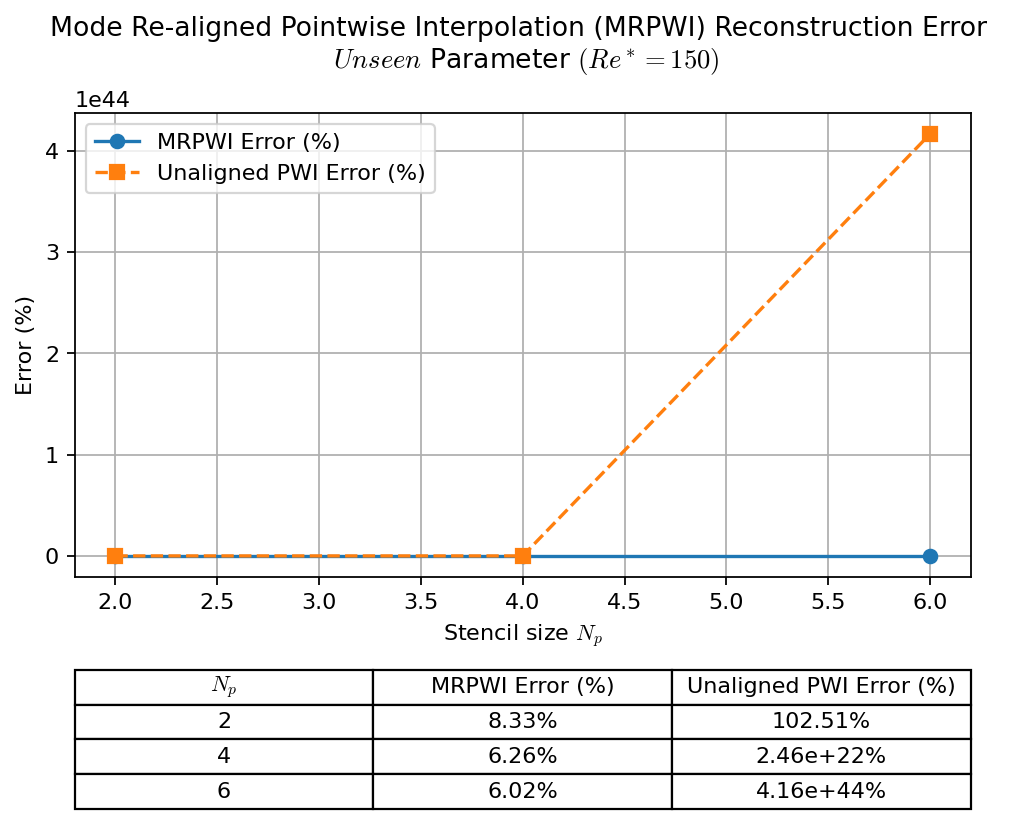

In [16]:

# Print and plot reconstruction errors for test parameter
errors_aligned   = {}
errors_unaligned = {}

for Np in stencil_sets.keys():
    X_true = snapshot_test_future   # ground truth snapshots
    X_pred_aligned   = recon_results_aligned[Np]
    X_pred_unaligned = recon_results_unaligned[Np]

    # RMSE relative error
    err_aligned = np.linalg.norm(X_pred_aligned - X_true) / np.linalg.norm(X_true)
    err_unaligned = np.linalg.norm(X_pred_unaligned - X_true) / np.linalg.norm(X_true)

    # Convert to percentage
    errors_aligned[Np]   = 100 * err_aligned
    errors_unaligned[Np] = 100 * err_unaligned

# Convert results to sorted lists for plotting
Np_values = sorted(stencil_sets.keys())
err_aligned_list   = [errors_aligned[Np]   for Np in Np_values]
err_unaligned_list = [errors_unaligned[Np] for Np in Np_values]

# Plot percentage error vs stencil size
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(Np_values, err_aligned_list, 'o-', label="MRPWI Error (%)")
ax.plot(Np_values, err_unaligned_list, 's--', label="Unaligned PWI Error (%)")
ax.set_xlabel(r"Stencil size $N_p$")
ax.set_ylabel("Error (%)")
ax.set_title(f"Mode Re-aligned Pointwise Interpolation (MRPWI) Reconstruction Error \n $Unseen$ Parameter $(Re^*={Re_test})$", pad=10)
ax.legend()
ax.grid(True)

# Build table data

table_data = []
for Np, aligned, unaligned in zip(Np_values, err_aligned_list, err_unaligned_list):
    def fmt(val):
        # Use exponential if abs(val) >= 1e3 or <= 1e-2, else fixed-point
        if abs(val) >= 1e3 or (0 < abs(val) < 1e-2):
            return f"{val:.2e}%"   # exponential notation
        else:
            return f"{val:.2f}%"   # fixed-point notation

    table_data.append([Np, fmt(aligned), fmt(unaligned)])

# Add table below plot
table = plt.table(cellText=table_data,
                  colLabels=["$N_p$", "MRPWI Error (%)", "Unaligned PWI Error (%)"],
                  loc="bottom",
                  cellLoc="center",
                  bbox=[0.0, -0.5, 1.0, 0.3])  # adjust vertical placement

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.2)


# Adjust layout to fit table
plt.subplots_adjust(left=0.1, bottom=0.3)

plt.show()


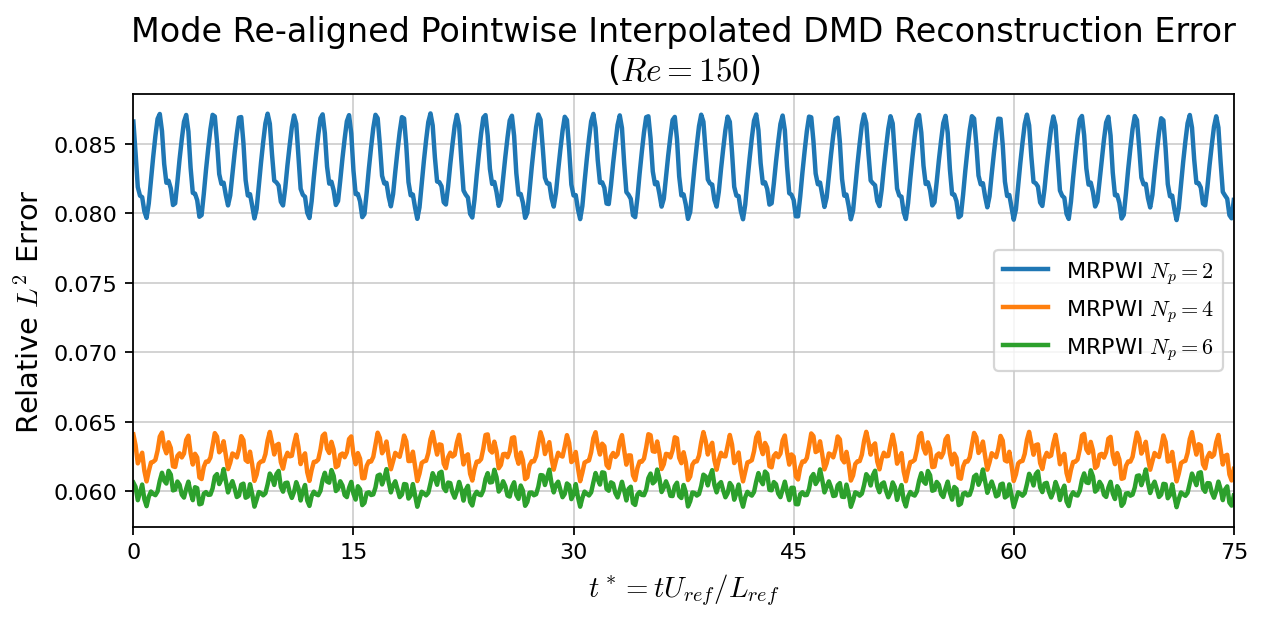

In [17]:
# Plot MRPWI reconstruction errors over interpolated time across stencil sizes for test parameter i.e., Reynolds number

Re_test = Re_test   # target Reynolds number
t_vec = np.array(sampled_times_test_future, dtype=float)  # ensure numeric time vector
X_true = snapshot_test_future[:, :len(t_vec)]             # true CFD snapshots

# Non-dimensionalize time vector
U_ref = U_ref_test
time_nd = (t_vec - t_vec[0]) * U_ref / L_ref

fig, ax = plt.subplots(figsize=(8,4))

for Np in stencil_sets.keys():
    # Aligned reconstruction
    X_recon_aligned = recon_results_aligned[Np].real
    abs_error_aligned = np.linalg.norm(X_true - X_recon_aligned, axis=0)
    rel_error_aligned = abs_error_aligned / np.linalg.norm(X_true, axis=0)
    ax.plot(time_nd, rel_error_aligned, lw=2, label=f"MRPWI $N_p={Np}$")

    # Unaligned reconstruction (optional)
    # X_recon_unaligned = recon_results_unaligned[Np].real
    # abs_error_unaligned = np.linalg.norm(X_true - X_recon_unaligned, axis=0)
    # rel_error_unaligned = abs_error_unaligned / np.linalg.norm(X_true, axis=0)
    # ax.plot(time_nd, rel_error_unaligned, '--', lw=1.5, label=f"Unaligned $N_p={Np}$")

# Axis labels and title
ax.set_xlabel(r"$t^* = t U_{ref}/L_{ref}$", fontsize=13)
ax.set_ylabel("Relative $L^2$ Error", fontsize=13)
ax.set_title(f"Mode Re-aligned Pointwise Interpolated DMD Reconstruction Error\n($Re = {Re_test}$)", fontsize=15)

# Grid and legend
ax.grid(True, alpha=0.6)
ax.legend()

# Force x-axis to match data range and ticks
ax.set_xlim(0, time_nd[-1])
ax.set_xticks(np.linspace(0, time_nd[-1], 6))

plt.tight_layout()
plt.show()


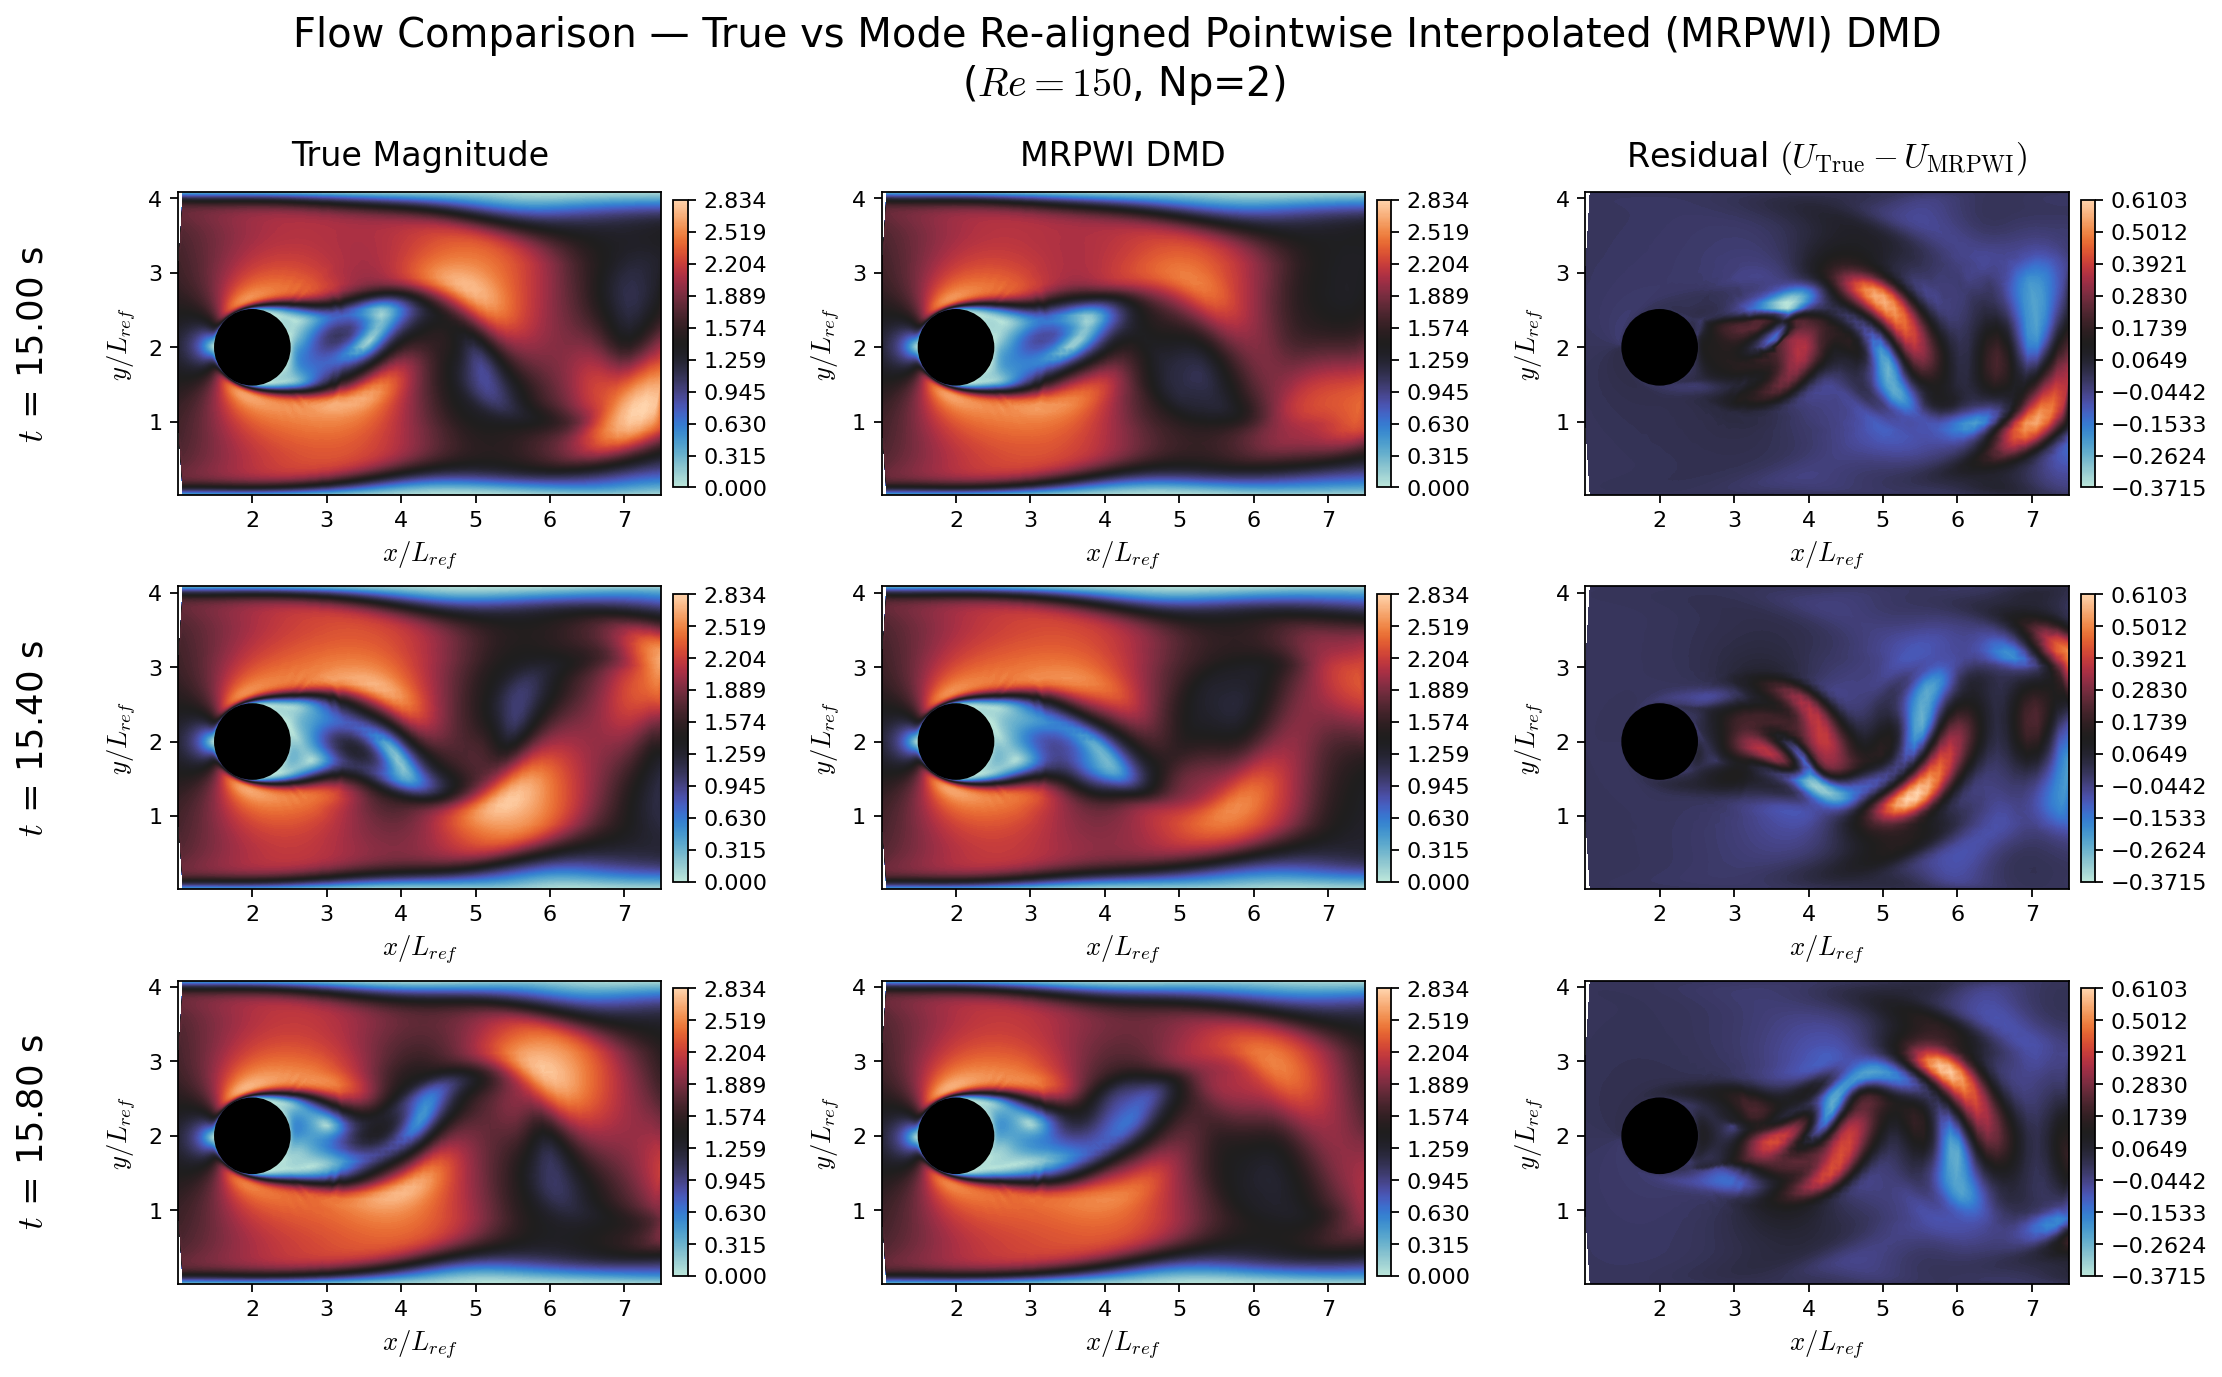

In [ ]:
# Plot flow comparison True vs Interpolated MRPWI for unseen parameter (i.e.,Reynolds number)

Re_test = Re_test
t_start, t_end = 15.0, 16.0
granularity = 40
Np_vis = 2  # stencil size for visualization

# Time vector
time_vec = np.array(sampled_times_test_future, dtype=float)
mask     = (time_vec >= t_start) & (time_vec <= t_end)
indices  = np.where(mask)[0][::granularity]

# Spatial setup
coords     = coords_test / L_ref   # non-dimensionalized
x_flat, y_flat = coords[:, 0], coords[:, 1]
num_points = num_points_test
tri        = mtri.Triangulation(x_flat, y_flat)

# True snapshots
X_true = snapshot_test_future[:, :len(time_vec)]

# Reconstructions
X_recon_aligned = recon_results_aligned[Np_vis]

# Precompute magnitudes
true_mags, recon_mags, resid_mags = [], [], []
for i in indices:
    ux_true, uy_true = np.real(X_true[:num_points, i]), np.real(X_true[num_points:, i])
    ux_recon, uy_recon = np.real(X_recon_aligned[:num_points, i]), np.real(X_recon_aligned[num_points:, i])
    mag_true  = np.sqrt(ux_true**2 + uy_true**2)
    mag_recon = np.sqrt(ux_recon**2 + uy_recon**2)
    mag_resid = mag_true - mag_recon
    true_mags.append(mag_true)
    recon_mags.append(mag_recon)
    resid_mags.append(mag_resid)

# Global color limits
vmin = min(m.min() for m in true_mags + recon_mags)
vmax = max(m.max() for m in true_mags + recon_mags)

# Shared normalization for True/Recon
norm_main   = Normalize(vmin=vmin, vmax=vmax)
sm_shared   = ScalarMappable(norm=norm_main, cmap="icefire"); sm_shared.set_array([])
fixed_ticks_main = np.linspace(vmin, vmax, 10)

# Residual scaling
resid_min = min(m.min() for m in resid_mags)
resid_max = max(m.max() for m in resid_mags)
sm_resid  = ScalarMappable(norm=Normalize(vmin=resid_min, vmax=resid_max), cmap="icefire"); sm_resid.set_array([])
fixed_ticks_resid = np.linspace(resid_min, resid_max, 10)

# Plot
num_rows = len(indices)
fig, axes = plt.subplots(num_rows, 3, figsize=(14, 3 * num_rows))
fig.suptitle(f"Flow Comparison — True vs Mode Re-aligned Pointwise Interpolated (MRPWI) DMD \n($Re = {Re_test}$, Np={Np_vis})", fontsize=18, y=0.96)

if num_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row, i in enumerate(indices):
    t_val = time_vec[i]
    mags  = [true_mags[row], recon_mags[row], resid_mags[row]]

    # True plot
    ax_true = axes[row, 0]
    ax_true.tricontourf(tri, mags[0], levels=200, cmap="icefire", vmin=vmin, vmax=vmax)
    ax_true.add_patch(Circle((cylinderX/L_ref, cylinderY/L_ref), radius/L_ref, color="black", zorder=10))
    ax_true.set_aspect("equal")
    fig.colorbar(sm_shared, ax=ax_true, shrink=0.95, pad=0.02, ticks=fixed_ticks_main)
    ax_true.text(-0.30, 0.5, f"$t$ = {t_val:.2f} s",
                 transform=ax_true.transAxes,
                 fontsize=16, rotation=90,
                 va="center", ha="center",
                 bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))

    # Reconstruction plot
    ax_recon = axes[row, 1]
    ax_recon.tricontourf(tri, mags[1], levels=200, cmap="icefire", vmin=vmin, vmax=vmax)
    ax_recon.add_patch(Circle((cylinderX/L_ref, cylinderY/L_ref), radius/L_ref, color="black", zorder=10))
    ax_recon.set_aspect("equal")
    fig.colorbar(sm_shared, ax=ax_recon, shrink=0.95, pad=0.02, ticks=fixed_ticks_main)

    # Residual plot
    ax_res = axes[row, 2]
    ax_res.tricontourf(tri, mags[2], levels=200, cmap="icefire", vmin=resid_min, vmax=resid_max)
    ax_res.add_patch(Circle((cylinderX/L_ref, cylinderY/L_ref), radius/L_ref, color="black", zorder=10))
    ax_res.set_aspect("equal")
    fig.colorbar(sm_resid, ax=ax_res, shrink=0.95, pad=0.02, ticks=fixed_ticks_resid)

    # Non-dimensional axis labels
    for ax in [ax_true, ax_recon, ax_res]:
        ax.set_xlabel(r"$x/L_{ref}$", fontsize=12)
        ax.set_ylabel(r"$y/L_{ref}$", fontsize=12)
        ax.tick_params(labelbottom=True, labelleft=True)

# Column titles only once
axes[0, 0].set_title("True Magnitude", fontsize=15, pad=12,
                     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))
axes[0, 1].set_title("MRPWI DMD", fontsize=15, pad=12,
                     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))
axes[0, 2].set_title(r"Residual $(U_{\mathrm{True}} - U_{\mathrm{MRPWI}})$", fontsize=15, pad=12,
                     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))

plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=2.0)
plt.show()


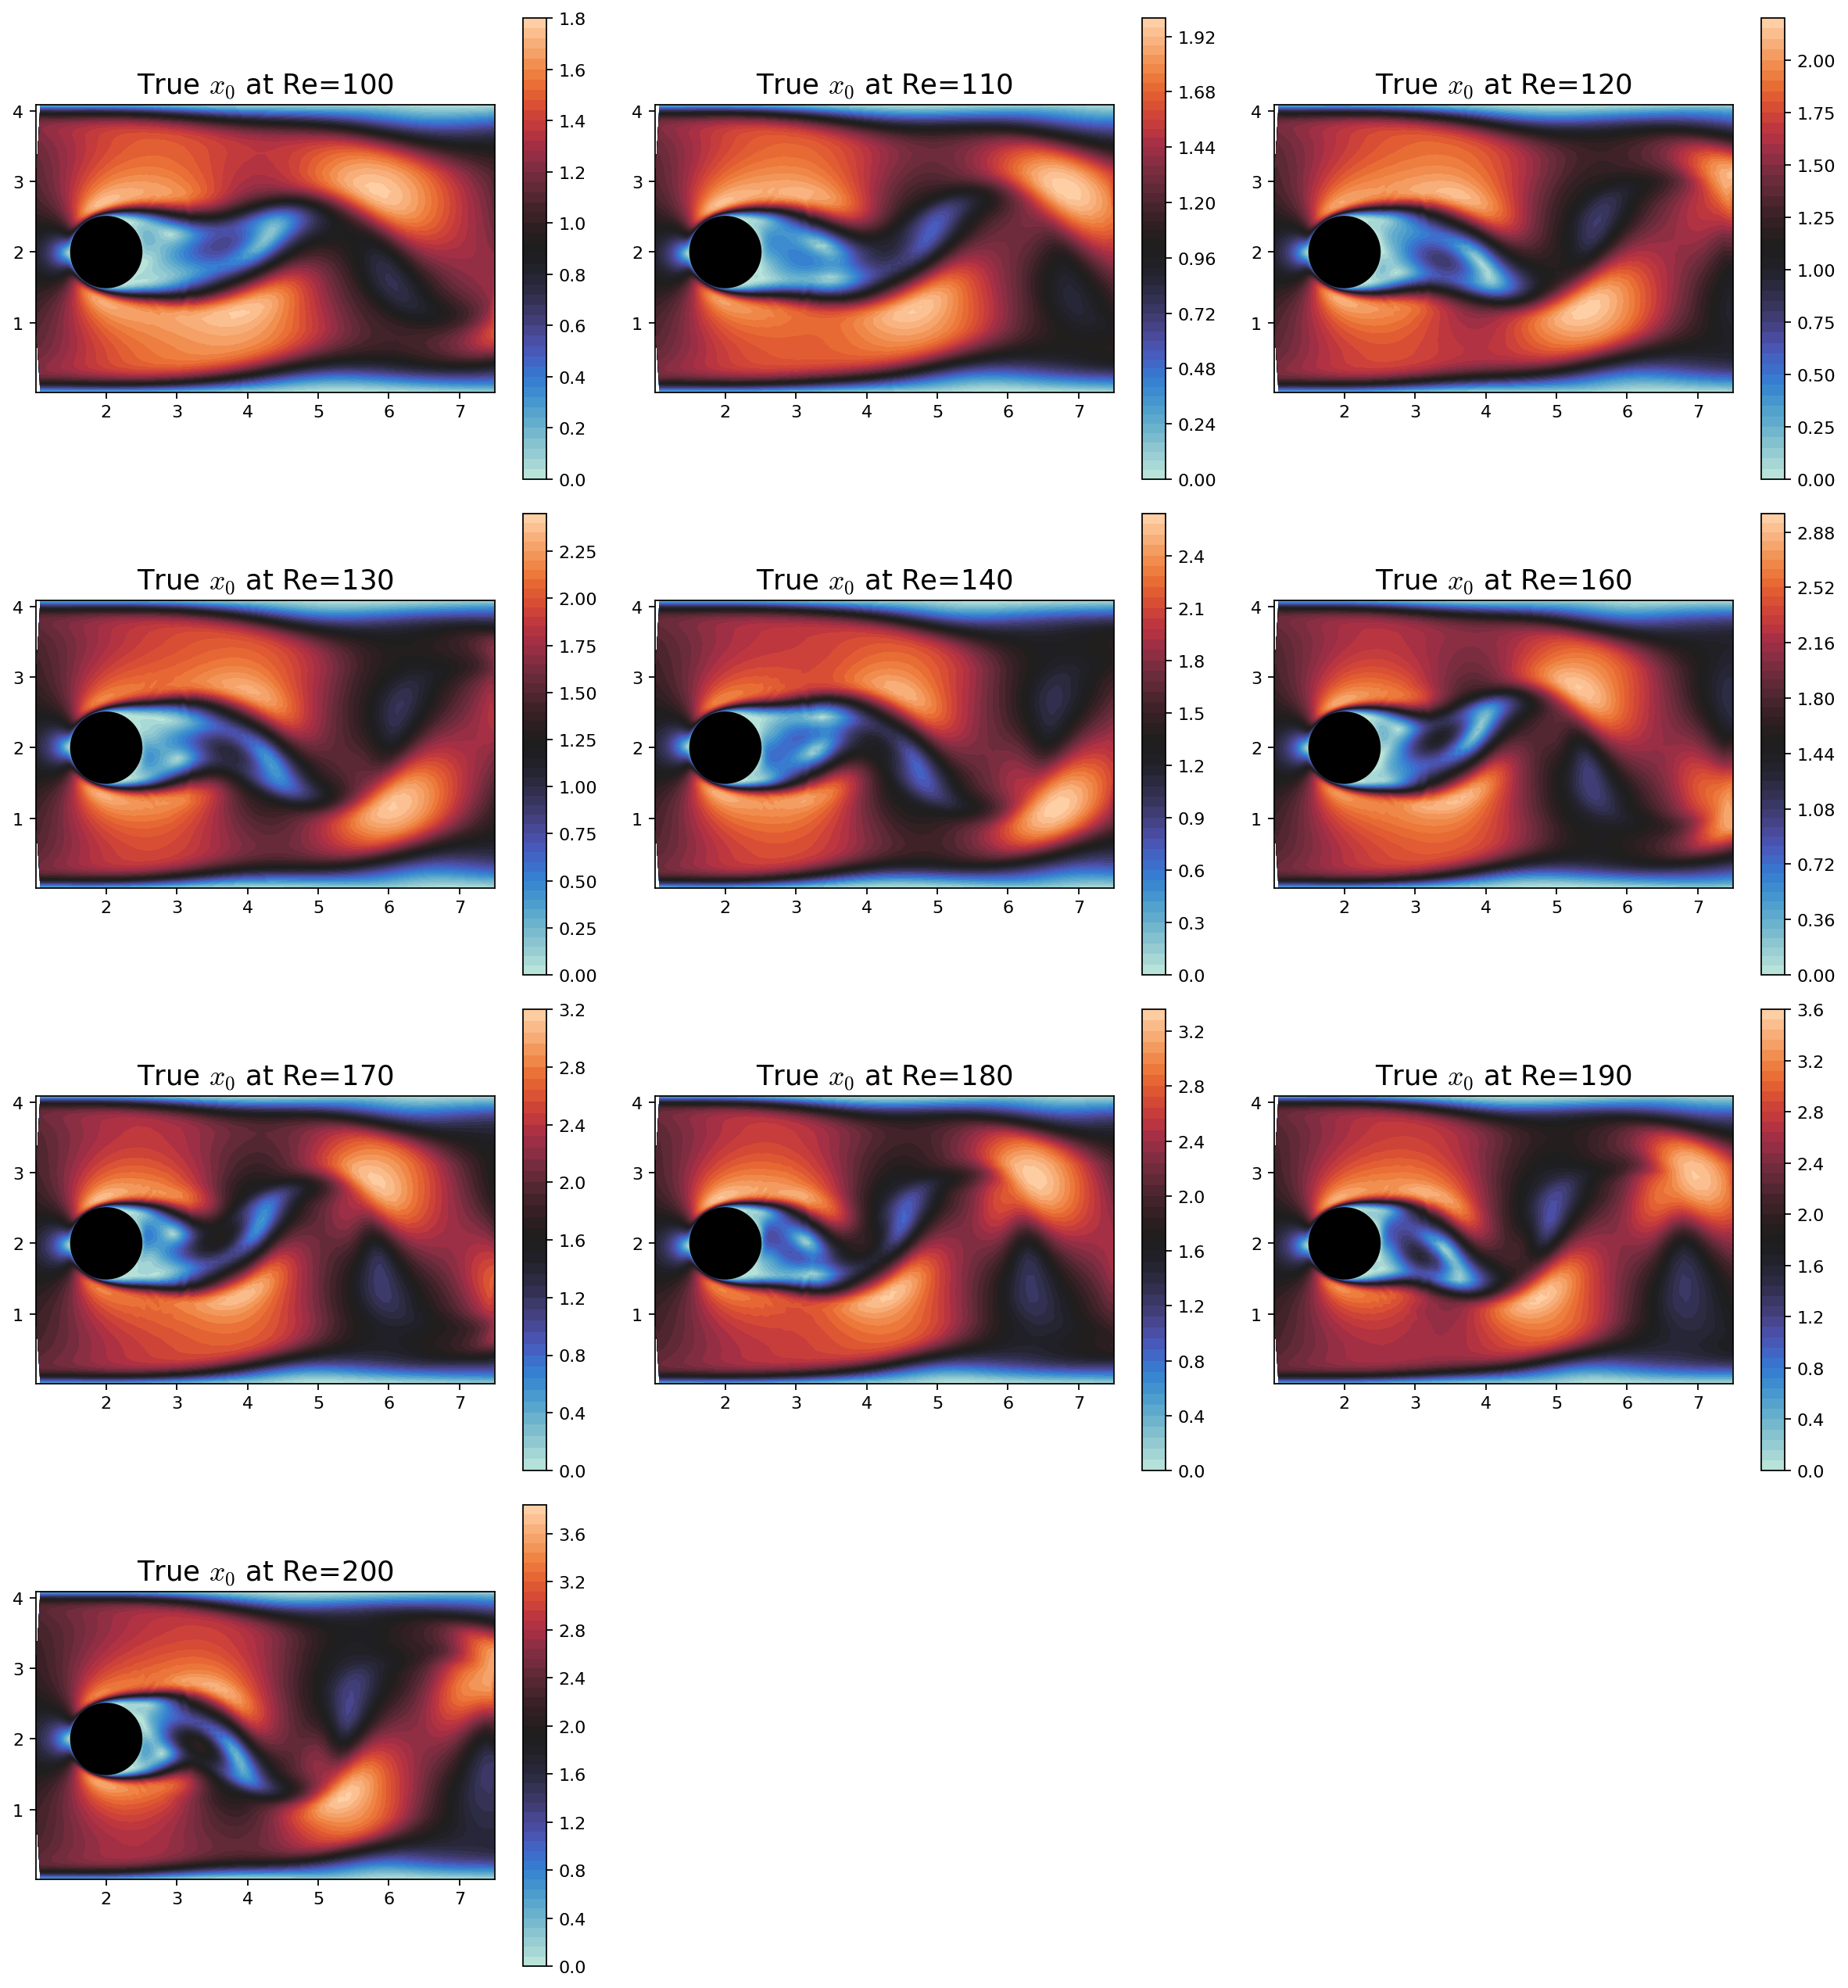

In [39]:
# Plot initial conditions for each training parameter 

# Number of Reynolds numbers
nRe = len(Re_list)

# Choose grid layout (square-ish)
ncols = 3
nrows = int(np.ceil(nRe / ncols))

# Coordinates
x = coords[:, 0]
y = coords[:, 1]

plt.figure(figsize=(5*ncols, 4*nrows))

for i, Re in enumerate(Re_list):

    # TRUE initial condition for this Re
    x0_true = snapshot_dict[Re][:, -1]

    # Split into u and v
    Ux_true = x0_true[:num_points]
    Uy_true = x0_true[num_points:]
    mag_true = np.sqrt(Ux_true**2 + Uy_true**2)

    ax = plt.subplot(nrows, ncols, i+1)

    # Plot magnitude
    tcf = ax.tricontourf(x, y, mag_true, levels=50, cmap='icefire')
    plt.colorbar(tcf, ax=ax)

    ax.set_title(f"True $x_0$ at Re={Re}", fontsize = 16)
    ax.set_aspect("equal")

    # Draw cylinder
    circle = plt.Circle((2, 2), 0.5, color='black', zorder=10)
    ax.add_patch(circle)
plt.tight_layout()
plt.show()
